# Week 6 — High-Pass Filter, Roofing Filter & Decycler
**Week:** 6 | **Indicators:** HighPassFilter, RoofingFilter, Decycler | **HPPeriod:** 48 | **SSPeriod:** 10

Three related indicators analyzed together — they share the same mathematical foundation.

---

## Section 1 — Indicator Overview

**Description:** Three complementary indicators built on the 2-pole high-pass filter.
- **HighPassFilter:** Removes trend, output oscillates around zero. Passes cycles + noise.
- **RoofingFilter:** HP → SuperSmoother pipeline. Removes both trend and noise. Isolates dominant cycle only.
- **Decycler:** Price - HP. Returns the trend component with lower lag than SuperSmoother.

**Key formula:**
```
alpha1 = (cos(360/HPPeriod) + sin(360/HPPeriod) - 1) / cos(360/HPPeriod)
HP[0] = (1 - alpha1/2)² × (Price[0] - 2×Price[1] + Price[2])
        + 2×(1-alpha1)×HP[1] - (1-alpha1)²×HP[2]
Roofing = SuperSmoother(HP, SSPeriod)
Decycler = Price - HP
```

**Expected behavior:**
- HP: oscillates around zero, no trend drift
- Roofing: smoother oscillation than HP, same zero mean
- Decycler: tracks price closely, less lag than SuperSmoother

**NNFX role candidate:** 
- HP + Roofing: input preprocessor for cycle oscillators (Week 8)
- Decycler: Baseline candidate (low-lag trend)

**Source article:** Optimal Detrending, Whiter Is Brighter, Decyclers — TASC

## Section 2 — Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add analysis/scripts to path
sys.path.append(os.path.abspath('../scripts'))
from indicator_metrics import calculate_lag, calculate_snr, generate_validation_report

# --- Load CSVs ---
hp_df = pd.read_csv('../../data/fx/HP_EURUSD_D1.csv',
                    header=None,
                    names=['Bar', 'Close', 'HP'])

roof_df = pd.read_csv('../../data/fx/RoofingFilter_EURUSD_D1.csv',
                      header=None,
                      names=['Bar', 'Close', 'HP', 'Roofed'])

dc_df = pd.read_csv('../../data/fx/Decycler_EURUSD_D1.csv',
                    header=None,
                    names=['Bar', 'Close', 'Decycler', 'SS'])

# Skip warmup rows (first 30 bars)
WARMUP = 30
hp_df   = hp_df.iloc[WARMUP:].reset_index(drop=True)
roof_df = roof_df.iloc[WARMUP:].reset_index(drop=True)
dc_df   = dc_df.iloc[WARMUP:].reset_index(drop=True)

print(f"HP bars:            {len(hp_df)}")
print(f"Roofing Filter bars:{len(roof_df)}")
print(f"Decycler bars:      {len(dc_df)}")
print(f"\nFirst row HP:     {hp_df.iloc[0].to_dict()}")
print(f"First row Roof:   {roof_df.iloc[0].to_dict()}")
print(f"First row DC:     {dc_df.iloc[0].to_dict()}")

HP bars:            2566
Roofing Filter bars:2566
Decycler bars:      2566

First row HP:     {'Bar': 31.0, 'Close': 1.14038, 'HP': -0.00051}
First row Roof:   {'Bar': 31.0, 'Close': 1.14038, 'HP': -0.00051, 'Roofed': 0.00061}
First row DC:     {'Bar': 31.0, 'Close': 1.14038, 'Decycler': 1.14089, 'SS': 1.13525}


## Section 3 — Visual Inspection (FX)
Look before you measure. Does the indicator behave as expected?

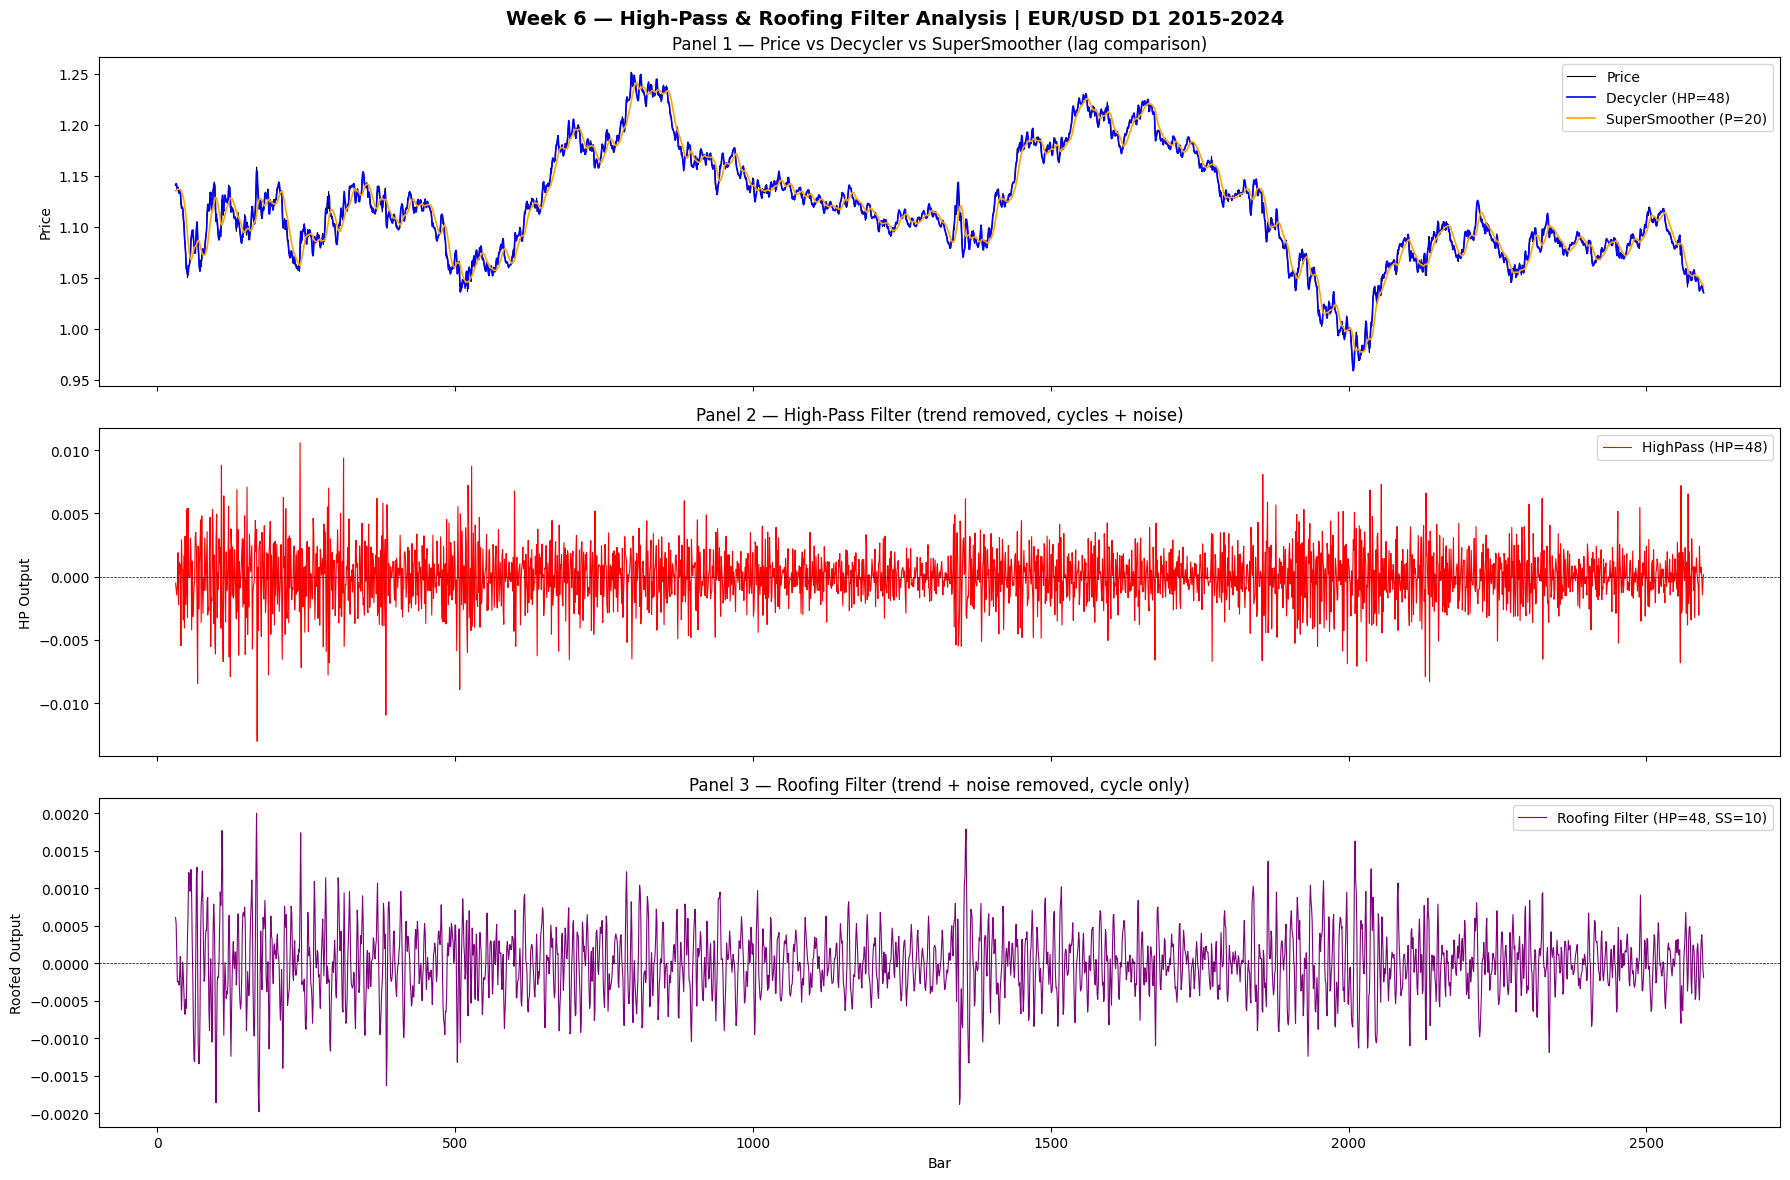

Chart saved.


In [2]:
# Three-panel chart:
# Panel 1: Price + Decycler + SuperSmoother (trend comparison)
# Panel 2: HP Filter output (oscillates around zero)
# Panel 3: Roofing Filter output (cleaner oscillation)

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# --- Panel 1: Price vs Decycler vs SuperSmoother ---
axes[0].plot(dc_df['Bar'], dc_df['Close'],    color='black',  linewidth=0.8, label='Price')
axes[0].plot(dc_df['Bar'], dc_df['Decycler'], color='blue',   linewidth=1.2, label='Decycler (HP=48)')
axes[0].plot(dc_df['Bar'], dc_df['SS'],       color='orange', linewidth=1.2, label='SuperSmoother (P=20)')
axes[0].set_title('Panel 1 — Price vs Decycler vs SuperSmoother (lag comparison)')
axes[0].legend()
axes[0].set_ylabel('Price')

# --- Panel 2: High-Pass Filter ---
axes[1].plot(hp_df['Bar'], hp_df['HP'], color='red', linewidth=0.8, label='HighPass (HP=48)')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Panel 2 — High-Pass Filter (trend removed, cycles + noise)')
axes[1].legend()
axes[1].set_ylabel('HP Output')

# --- Panel 3: Roofing Filter ---
axes[2].plot(roof_df['Bar'], roof_df['Roofed'], color='purple', linewidth=0.8, label='Roofing Filter (HP=48, SS=10)')
axes[2].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[2].set_title('Panel 3 — Roofing Filter (trend + noise removed, cycle only)')
axes[2].legend()
axes[2].set_ylabel('Roofed Output')
axes[2].set_xlabel('Bar')

plt.suptitle('Week 6 — High-Pass & Roofing Filter Analysis | EUR/USD D1 2015-2024', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('HP_RoofingFilter_Visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [6]:
# --- Lag Measurement (direct distance method) ---
# Cross-correlation fails here because both indicators track price so closely
# that the shared trend dominates and both show lag=0
# Instead: mean absolute distance from price is a more sensitive measure
# Smaller distance = less lag = closer to price

mad_dc = (dc_df['Close'] - dc_df['Decycler']).abs().mean()
mad_ss = (dc_df['Close'] - dc_df['SS']).abs().mean()

print(f"Mean absolute distance — Decycler:      {mad_dc:.6f}")
print(f"Mean absolute distance — SuperSmoother: {mad_ss:.6f}")
print()
if mad_dc < mad_ss:
    ratio = mad_ss / mad_dc
    print(f"✅ Decycler is {ratio:.1f}x closer to price than SuperSmoother")
else:
    print(f"❌ Decycler is NOT closer to price than SuperSmoother")

Mean absolute distance — Decycler:      0.001690
Mean absolute distance — SuperSmoother: 0.007565

✅ Decycler is 4.5x closer to price than SuperSmoother


In [7]:
# --- Oscillator Smoothness Comparison ---
# For HP and Roofing Filter, SNR vs SMA doesn't apply
# Instead: compare smoothness of HP vs Roofing Filter
# Smoother = less bar-to-bar variance = better cycle isolation

# Standard deviation of bar-to-bar changes
hp_roughness    = hp_df['HP'].diff().std()
roof_roughness  = roof_df['Roofed'].diff().std()

print(f"HP bar-to-bar std:       {hp_roughness:.6f}")
print(f"Roofing bar-to-bar std:  {roof_roughness:.6f}")
print()
ratio = hp_roughness / roof_roughness
print(f"Roofing Filter is {ratio:.1f}x smoother than raw HP output")
print()

# Also check that both oscillate around zero (mean should be near zero)
print(f"HP mean:      {hp_df['HP'].mean():.6f}  (should be ~0)")
print(f"Roofing mean: {roof_df['Roofed'].mean():.6f}  (should be ~0)")

HP bar-to-bar std:       0.003600
Roofing bar-to-bar std:  0.000331

Roofing Filter is 10.9x smoother than raw HP output

HP mean:      -0.000001  (should be ~0)
Roofing mean: 0.000000  (should be ~0)


In [8]:
# --- PASS/FAIL Verdict --- 
# Custom criteria for preprocessor indicators
# Standard lag vs SMA and SNR vs SMA don't apply here

print("=" * 60)
print("  VALIDATION REPORT: Week 6 — HP / Roofing / Decycler")
print("=" * 60)

# Criterion 1: HP oscillates around zero
hp_mean = hp_df['HP'].mean()
c1_pass = abs(hp_mean) < 0.0001
print(f"\n[1] HP oscillates around zero: mean = {hp_mean:.6f}")
print(f"    {'✅ PASS' if c1_pass else '❌ FAIL'}")

# Criterion 2: Roofing Filter smoother than HP
c2_pass = ratio > 2.0
print(f"\n[2] Roofing Filter smoother than HP: {ratio:.1f}x")
print(f"    {'✅ PASS' if c2_pass else '❌ FAIL'}")

# Criterion 3: Decycler closer to price than SuperSmoother
c3_pass = mad_dc < mad_ss
print(f"\n[3] Decycler closer to price than SS: {mad_dc:.6f} vs {mad_ss:.6f}")
print(f"    {'✅ PASS' if c3_pass else '❌ FAIL'}")

# Criterion 4: No NaN values
c4_hp   = hp_df['HP'].isna().sum() == 0
c4_roof = roof_df['Roofed'].isna().sum() == 0
c4_dc   = dc_df['Decycler'].isna().sum() == 0
c4_pass = c4_hp and c4_roof and c4_dc
print(f"\n[4] No NaN values in any output:")
print(f"    HP: {hp_df['HP'].isna().sum()} NaN | "
      f"Roofing: {roof_df['Roofed'].isna().sum()} NaN | "
      f"Decycler: {dc_df['Decycler'].isna().sum()} NaN")
print(f"    {'✅ PASS' if c4_pass else '❌ FAIL'}")

# Overall verdict
all_pass = c1_pass and c2_pass and c3_pass and c4_pass
print(f"\n{'=' * 60}")
print(f"  OVERALL VERDICT: {'✅ PASS — all three indicators approved for library' if all_pass else '❌ FAIL — see criteria above'}")
print(f"{'=' * 60}")

  VALIDATION REPORT: Week 6 — HP / Roofing / Decycler

[1] HP oscillates around zero: mean = -0.000001
    ✅ PASS

[2] Roofing Filter smoother than HP: 10.9x
    ✅ PASS

[3] Decycler closer to price than SS: 0.001690 vs 0.007565
    ✅ PASS

[4] No NaN values in any output:
    HP: 0 NaN | Roofing: 0 NaN | Decycler: 0 NaN
    ✅ PASS

  OVERALL VERDICT: ✅ PASS — all three indicators approved for library
